# Measurement bias of the benchmark, qubit by qubit

The LR-QAOA circuits of `benchmark_codes_ibm.ipynb` end by measuring every data qubit, and the Hamiltonian a
surface-code patch encodes is a sum of products of an **even** number of $Z$ operators. Flipping every data qubit
therefore leaves every term unchanged, so the noiseless output distribution is invariant under a global bit flip
and **every single-qubit marginal is exactly $1/2$**, at any depth. Section 2 checks this rather than assuming it.

That makes the benchmark a bias meter for free: any departure of $P(1)$ from $1/2$ on a data qubit is noise, not
algorithm. This notebook measures that departure in both frames of the benchmark - $Z$, where the data rest in
$Z$ eigenstates between layers, and $X$, where they rest in $X$ eigenstates - and asks

* how large the bias is, how it grows with depth and where it saturates;
* whether it is the same qubits in both frames;
* whether the device's own calibration predicts which qubits are biased;
* what the bias does to $r$ itself, and whether the random baseline is still the right floor.

It only reads `data/`: no account, nothing is sent. This is a study of the runs already harvested, not part of the
benchmark library.

In [ ]:
import json
import sys
from collections import defaultdict
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))          # not needed after `pip install -e .`
DATA, FIGURES = ROOT / "data", ROOT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr

from qecbench import codes
from qecbench.lrqaoa import bitstring_energies, ideal_probabilities
from qecbench.primitives import CodePatch

## 1. Configuration - the only cell you normally edit

`RUN` is the stamp of a benchmark run that was taken in **both** frames; `None` takes the newest one, preferring
whichever reaches the greatest depth. The two frames are read from the files `<stamp>_<backend>_surface_code_mcm`
and `..._mcm_x`, so they are the same qubits measured minutes apart.

In [ ]:
BACKEND  = "ibm_phoenix"
DISTANCE = 3                                   # d = 3 keeps the noiseless check exact: 2**9 amplitudes
RUN      = None                                # e.g. "20260928_0900"; None takes the deepest recent pair
SURFACE  = DATA / "results" / BACKEND / "surface_code"

pairs = {}
for x_path in sorted((SURFACE / "mcm_x").glob("*.json")):
    z_path = SURFACE / "mcm" / x_path.name.replace("_mcm_x", "_mcm")
    if z_path.exists():
        pairs[x_path.name[:13]] = (z_path, x_path)
if RUN is not None:
    stamp = next(k for k in pairs if k.startswith(RUN))
else:
    reach = {}
    for k, (z_path, _) in pairs.items():
        got = json.loads(z_path.read_text())["results"]
        depths = [r["parameters"]["depth"] for r in got
                  if r["benchmark"]["instance"]["code"]["name"] == f"surface_d{DISTANCE}"]
        reach[k] = (max(depths, default=0), k)
    stamp = max(reach, key=reach.get)
files = pairs[stamp]
print(f"{len(pairs)} runs carry both frames; using {stamp}")
print(f"   Z frame {files[0].name}\n   X frame {files[1].name}")

8 runs carry both frames; using 20260928_0900
   Z frame 20260928_090055_ibm_phoenix_surface_code_mcm.json
   X frame 20260928_090055_ibm_phoenix_surface_code_mcm_x.json


## 2. The noiseless marginals really are $1/2$

Everything below rests on this, so it is computed rather than asserted: the exact output distribution of the
noiseless depth-$p$ LR-QAOA on a $d = 3$ patch, marginalised onto each data qubit. `ideal_probabilities` builds the
$2^9$ amplitudes directly, so this is exact, not sampled.

In [ ]:
code_d = codes.surface_code(DISTANCE)
patch_d = CodePatch(code_d, kind="mcm")
n_data = patch_d.n_data
print(f"surface_d{DISTANCE}: {len(code_d.hamiltonian)} terms, supports "
      f"{sorted({len(t) for t in code_d.hamiltonian})}, all of even weight: "
      f"{all(len(t) % 2 == 0 for t in code_d.hamiltonian)}")
bits_table = np.array([[int(c) for c in format(k, f"0{n_data}b")] for k in range(2 ** n_data)])
print(f"\n{'depth':>6} {'max |P(1) - 1/2| over the data qubits':>40}")
for depth in (1, 2, 3, 5, 10):
    marginals = ideal_probabilities(code_d.hamiltonian, n_data, depth) @ bits_table
    print(f"{depth:>6} {np.abs(marginals - 0.5).max():>40.2e}")

surface_d3: 8 terms, supports [2, 4], all of even weight: True

 depth    max |P(1) - 1/2| over the data qubits
     1                                 3.89e-16
     2                                 1.17e-15
     3                                 8.88e-16
     5                                 7.77e-16
    10                                 1.28e-15


## 3. The measured bias, by depth and by frame

For every $d = $ `DISTANCE` circuit of the run, the fraction of shots in which each data qubit read 1, minus
$1/2$. Negative means the qubit was pulled toward $|0\rangle$. The figure shows the mean over all data qubits of
every patch, with bars for the spread **between qubits** - which is the interesting quantity here, since a bias
that were common to the whole chip would be a calibration offset, while one that differs qubit by qubit is not.

mean bias P(1) - 1/2 over every d = 3 data qubit, and its spread between qubits

 frame        p=1       p=2       p=3       p=5       p=7      p=10      p=12      p=15      p=20
     Z    -0.0410   -0.1105   -0.1405   -0.1399   -0.1195   -0.1181   -0.1329   -0.1405   -0.1498
          +-0.042   +-0.099   +-0.133   +-0.153   +-0.137   +-0.116   +-0.111   +-0.098   +-0.085
     X    -0.0119   -0.0249   -0.0271   -0.0205   -0.0170   -0.0149   -0.0157   -0.0170   -0.0164
          +-0.019   +-0.025   +-0.026   +-0.031   +-0.031   +-0.029   +-0.025   +-0.027   +-0.025


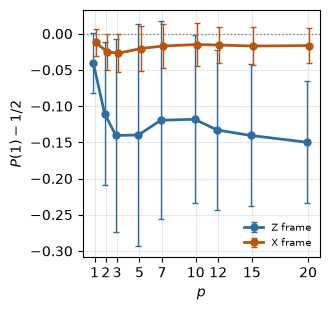

In [ ]:
def per_qubit_bias(path):
    # {physical qubit: [P(1) - 1/2, once per patch it appears in]} and the same split by depth
    by_qubit, by_depth = defaultdict(list), defaultdict(list)
    for record in json.loads(Path(path).read_text())["results"]:
        if record["benchmark"]["instance"]["code"]["name"] != f"surface_d{DISTANCE}":
            continue
        counts, parameters = record["samples"], record["parameters"]
        keys = list(counts)
        bits = np.frombuffer("".join(keys).encode(), dtype=np.uint8).reshape(len(keys), -1) - 48
        weights = np.array([counts[k] for k in keys], float)
        bias = (weights @ bits) / weights.sum() - 0.5          # character i is data qubit i
        for qubit, value in zip(parameters["data_qubits"], bias):
            by_qubit[qubit].append(value)
            by_depth[parameters["depth"]].append(value)
    return by_qubit, by_depth


bias = {}
for frame, path in (("Z", files[0]), ("X", files[1])):
    bias[frame] = per_qubit_bias(path)
depths = sorted(bias["Z"][1])
print(f"mean bias P(1) - 1/2 over every d = {DISTANCE} data qubit, and its spread between qubits\n")
print(f"{'frame':>6} " + "".join(f"{'p=' + str(p):>10}" for p in depths))
for frame in ("Z", "X"):
    print(f"{frame:>6} " + "".join(f"{np.mean(bias[frame][1][p]):>+10.4f}" for p in depths))
    print(f"{'':>6} " + "".join(f"{'+-' + format(np.std(bias[frame][1][p]), '.3f'):>10}" for p in depths))

fig, ax = plt.subplots(figsize=(3.4, 3.2))
for frame, colour, dodge in (("Z", "#2f6f9f", -0.1), ("X", "#b8560f", 0.1)):
    middle = [np.mean(bias[frame][1][p]) for p in depths]
    spread = [np.std(bias[frame][1][p]) for p in depths]
    ax.errorbar(np.array(depths) + dodge, middle, yerr=spread, fmt="-o", color=colour, lw=2, ms=5,
                capsize=2.5, elinewidth=1, label=f"{frame} frame")
ax.axhline(0, color="0.5", ls=":", lw=1)
ax.set(xlabel="$p$", ylabel=r"$P(1) - 1/2$")
ax.set_xticks(depths)
ax.grid(alpha=0.3)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / f"{BACKEND}_bias_vs_depth.pdf", bbox_inches="tight")
plt.show()

## 4. Which qubits, and are they the same in both frames?

Each data qubit's bias averaged over every patch and depth it appears in. If the two frames disagreed completely
the scatter would be structureless; if the bias were one mechanism seen twice, the points would lie on a line.

68 data qubits
   Z frame: mean -0.1202, spread between qubits 0.0982, range -0.334 to +0.145
   X frame: mean -0.0171, spread between qubits 0.0200, range -0.147 to +0.020
   the same qubits in both frames? Pearson +0.40, Spearman +0.25

the ten most biased qubits of the Z frame
 qubit    Z bias    X bias
    37    -0.334    -0.035
    55    -0.310    -0.147
    82    -0.273    -0.021
    59    -0.267    -0.010
    41    -0.259    -0.029
    77    -0.258    -0.005
    35    -0.251    -0.005
   102    -0.250    -0.012
   101    -0.233    -0.011
    57    -0.228    -0.011


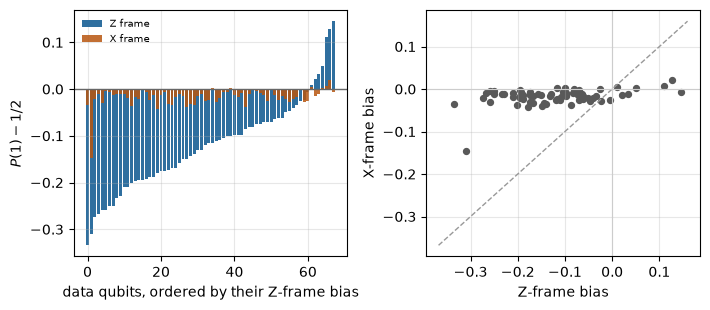

In [ ]:
common = sorted(set(bias["Z"][0]) & set(bias["X"][0]))
z_bias = np.array([np.mean(bias["Z"][0][q]) for q in common])
x_bias = np.array([np.mean(bias["X"][0][q]) for q in common])
print(f"{len(common)} data qubits")
for frame, values in (("Z", z_bias), ("X", x_bias)):
    print(f"   {frame} frame: mean {values.mean():+.4f}, spread between qubits {values.std():.4f}, "
          f"range {values.min():+.3f} to {values.max():+.3f}")
print(f"   the same qubits in both frames? Pearson {np.corrcoef(z_bias, x_bias)[0, 1]:+.2f}, "
      f"Spearman {spearmanr(z_bias, x_bias)[0]:+.2f}")
print(f"\nthe ten most biased qubits of the Z frame")
print(f"{'qubit':>6} {'Z bias':>9} {'X bias':>9}")
for q in sorted(common, key=lambda q: -abs(np.mean(bias["Z"][0][q])))[:10]:
    print(f"{q:>6} {np.mean(bias['Z'][0][q]):>+9.3f} {np.mean(bias['X'][0][q]):>+9.3f}")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
axes[0].bar(range(len(common)), sorted(z_bias), color="#2f6f9f", label="Z frame")
axes[0].bar(range(len(common)), [x for _, x in sorted(zip(z_bias, x_bias))], color="#b8560f", alpha=0.85,
            label="X frame")
axes[0].axhline(0, color="0.4", lw=1)
axes[0].set(xlabel="data qubits, ordered by their Z-frame bias", ylabel=r"$P(1) - 1/2$")
axes[0].legend(fontsize=7, frameon=False)
axes[1].scatter(z_bias, x_bias, s=18, color="0.35")
span = [min(z_bias.min(), x_bias.min()) * 1.1, max(z_bias.max(), x_bias.max()) * 1.1 + 1e-9]
axes[1].plot(span, span, "--", color="0.6", lw=1)
axes[1].axhline(0, color="0.8", lw=0.8)
axes[1].axvline(0, color="0.8", lw=0.8)
axes[1].set(xlabel="Z-frame bias", ylabel="X-frame bias")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / f"{BACKEND}_bias_by_qubit.pdf", bbox_inches="tight")
plt.show()

## 5. Does the calibration know which qubits are biased?

The snapshot taken closest before the run, against the same qubits. A mechanism that is simply relaxation would
show as a correlation with $T_1$: the shorter the lifetime, the harder the pull toward $|0\rangle$.

In [ ]:
snapshots = sorted((DATA / "calibration" / BACKEND).glob("*_calibration.json"))
created = json.loads(Path(files[0]).read_text())["run"]["created"]
before = [s for s in snapshots if json.loads(s.read_text())["fetched_at"] <= created]
calibration = json.loads((before[-1] if before else snapshots[0]).read_text())["one_qubit"]
print(f"calibration {(before[-1] if before else snapshots[0]).name}\n")
known = [q for q in common if str(q) in calibration]
z_known = np.array([np.mean(bias["Z"][0][q]) for q in known])
x_known = np.array([np.mean(bias["X"][0][q]) for q in known])
print(f"{'calibration quantity':>22} {'vs Z bias':>11} {'vs X bias':>11}   (Spearman over "
      f"{len(known)} qubits)")
for label, field in (("T1", "T1"), ("T2", "T2"), ("readout error", "readout_error"),
                     ("mid-circuit readout", "mcm_readout_error"), ("sx error", "sx_error")):
    values = np.array([calibration[str(q)].get(field, np.nan) for q in known], float)
    ok = np.isfinite(values)
    if ok.sum() >= 5:
        print(f"{label:>22} {spearmanr(values[ok], z_known[ok])[0]:>+11.2f} "
              f"{spearmanr(values[ok], x_known[ok])[0]:>+11.2f}")

calibration 20260928_0900_ibm_phoenix_calibration.json

  calibration quantity   vs Z bias   vs X bias   (Spearman over 68 qubits)
                    T1       +0.09       -0.03
                    T2       +0.15       +0.20
         readout error       -0.20       -0.12
   mid-circuit readout       -0.13       +0.04
              sx error       -0.33       -0.25


## 6. What the bias does to $r$, and to the random baseline

$r = 1/2$ is quoted as the score of guessing, and for a *uniform* random bitstring it is exactly that. A biased
product state is not uniform: every qubit reading $|0\rangle$ more often than $|1\rangle$ correlates the even-weight
terms of the Hamiltonian, and the all-zeros string sits at the top of the spectrum, $r = 0$. So a patch carrying no
coherence at all scores **below** $1/2$ once it is biased, and $r_{\rm ovl}$ goes negative without anything
interesting having happened.

The cell prices that: the $r$ of a fully decohered product state at the measured bias. Treat it as the floor a
patch is really being compared against, in place of the flat $1/2$.

all |0> and all |1> both sit at r = -0.000, the top of the spectrum

   bias b    P(1)   r of a decohered patch
    +0.00    0.50                    0.499
    -0.05    0.45                    0.496
    -0.10    0.40                    0.488
    -0.15    0.35                    0.474
    -0.20    0.30                    0.453
    -0.30    0.20                    0.377

at the Z frame's measured mean bias of -0.120, a decohered patch scores r = 0.482, not 0.500


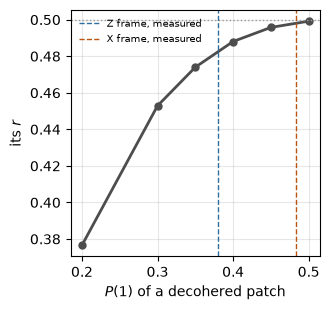

In [ ]:
hamiltonian = patch_d.hamiltonian
e_opt, e_max = patch_d.optimal_energy(), patch_d.max_energy()
r_of = lambda energy: (energy - e_max) / (e_opt - e_max)
print(f"all |0> and all |1> both sit at r = {r_of(bitstring_energies(['0' * n_data], hamiltonian)[0]):.3f}, "
      f"the top of the spectrum\n")
rng = np.random.default_rng(0)
print(f"{'bias b':>9} {'P(1)':>7} {'r of a decohered patch':>24}")
grid = [0.0, -0.05, -0.10, -0.15, -0.20, -0.30]
floor = {}
for b in grid:
    draws = (rng.random((20000, n_data)) < (0.5 + b)).astype(np.uint8)
    floor[b] = r_of(bitstring_energies(["".join(map(str, row)) for row in draws], hamiltonian).mean())
    print(f"{b:>+9.2f} {0.5 + b:>7.2f} {floor[b]:>24.3f}")
measured = np.mean([np.mean(v) for v in bias["Z"][0].values()])
print(f"\nat the Z frame's measured mean bias of {measured:+.3f}, a decohered patch scores "
      f"r = {np.interp(measured, grid[::-1], [floor[b] for b in grid[::-1]]):.3f}, not 0.500")

fig, ax = plt.subplots(figsize=(3.4, 3.2))
ax.plot([0.5 + b for b in grid], [floor[b] for b in grid], "-o", color="0.3", lw=2, ms=5)
ax.axhline(0.5, color="0.6", ls=":", lw=1)
ax.axvline(0.5 + measured, color="#2f6f9f", ls="--", lw=1, label="Z frame, measured")
ax.axvline(0.5 + np.mean([np.mean(v) for v in bias["X"][0].values()]), color="#b8560f", ls="--", lw=1,
           label="X frame, measured")
ax.set(xlabel="$P(1)$ of a decohered patch", ylabel="its $r$")
ax.grid(alpha=0.3)
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
fig.savefig(FIGURES / f"{BACKEND}_biased_baseline.pdf", bbox_inches="tight")
plt.show()

## 7. The same qubits on other days

One run cannot tell a per-qubit property from a one-off. This section repeats sections 3 and 4 on **every** run
that carries both frames and asks how much of the bias belongs to the qubit and how much to the day, by splitting
the variance: the spread of each qubit's run-averaged bias between qubits, against the spread of one qubit's bias
between runs. A number that is mostly the qubit is a property of the chip worth recording; one that is mostly the
day is a measurement of that morning.

8 runs with both frames

            run  qubits    Z mean   Z spread   Z worst    X mean   X spread
  20260922_1326      68   -0.1146     0.0846    -0.294   -0.0163     0.0204
  20260923_0715      68   -0.1171     0.0879    -0.285   -0.0181     0.0178
  20260923_1635      68   -0.1193     0.0915    -0.293   -0.0168     0.0189
  20260924_0804      68   -0.1101     0.0985    -0.274   -0.0173     0.0175
  20260926_0857      68   -0.1148     0.0959    -0.315   -0.0181     0.0213
  20260926_1311      68   -0.1144     0.0913    -0.306   -0.0157     0.0192
  20260928_0812      68   -0.1087     0.1040    -0.294   -0.0170     0.0165
  20260928_0900      68   -0.1202     0.0982    -0.334   -0.0171     0.0200

is a qubit's bias the same from run to run? Spearman between runs, on their shared qubits
   Z frame: mean +0.80, median +0.80, 28/28 pairs positive
   X frame: mean +0.60, median +0.63, 28/28 pairs positive

where the spread lives, over the 68 qubits measured in every run
  frame   betwee

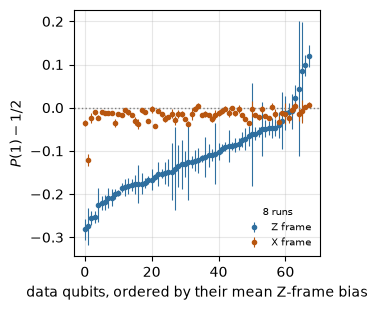

In [ ]:
runs = {}
for x_path in sorted((SURFACE / "mcm_x").glob("*.json")):
    z_path = SURFACE / "mcm" / x_path.name.replace("_mcm_x", "_mcm")
    if z_path.exists():
        runs[x_path.name[:13]] = {"Z": {q: float(np.mean(v)) for q, v in per_qubit_bias(z_path)[0].items()},
                                  "X": {q: float(np.mean(v)) for q, v in per_qubit_bias(x_path)[0].items()}}
stamps = list(runs)
print(f"{len(stamps)} runs with both frames\n")
print(f"{'run':>15} {'qubits':>7} {'Z mean':>9} {'Z spread':>10} {'Z worst':>9} {'X mean':>9} {'X spread':>10}")
for st in stamps:
    z = np.array(list(runs[st]["Z"].values()))
    x = np.array(list(runs[st]["X"].values()))
    print(f"{st:>15} {len(z):>7} {z.mean():>+9.4f} {z.std():>10.4f} {z.min():>+9.3f} "
          f"{x.mean():>+9.4f} {x.std():>10.4f}")

print(f"\nis a qubit's bias the same from run to run? Spearman between runs, on their shared qubits")
for frame in ("Z", "X"):
    values = []
    for i in range(len(stamps)):
        for k in range(i + 1, len(stamps)):
            a, b = runs[stamps[i]][frame], runs[stamps[k]][frame]
            shared = sorted(set(a) & set(b))
            if len(shared) >= 8:
                values.append(spearmanr([a[q] for q in shared], [b[q] for q in shared])[0])
    print(f"   {frame} frame: mean {np.mean(values):+.2f}, median {np.median(values):+.2f}, "
          f"{sum(1 for v in values if v > 0)}/{len(values)} pairs positive")

everywhere = sorted(set.intersection(*(set(runs[st]["Z"]) for st in stamps)))
grid = {frame: np.array([[runs[st][frame][q] for q in everywhere] for st in stamps]) for frame in ("Z", "X")}
print(f"\nwhere the spread lives, over the {len(everywhere)} qubits measured in every run")
print(f"{'frame':>7} {'between qubits':>16} {'within a qubit':>16} {'qubit share':>13}")
for frame in ("Z", "X"):
    between = grid[frame].mean(axis=0).std()
    within = np.mean(grid[frame].std(axis=0))
    print(f"{frame:>7} {between:>16.3f} {within:>16.3f} "
          f"{between ** 2 / (between ** 2 + within ** 2):>12.0%}")

print(f"\nthe eight most biased qubits of the Z frame, run by run")
print(f"{'qubit':>6} " + "".join(f"{st[4:8]:>8}" for st in stamps) + f"{'mean':>8}{'sd':>7}")
for q in sorted(everywhere, key=lambda q: np.mean([runs[st]["Z"][q] for st in stamps]))[:8]:
    row = [runs[st]["Z"][q] for st in stamps]
    print(f"{q:>6} " + "".join(f"{v:>+8.3f}" for v in row) + f"{np.mean(row):>+8.3f}{np.std(row):>7.3f}")

fig, ax = plt.subplots(figsize=(3.4, 3.2))
order = np.argsort(grid["Z"].mean(axis=0))
for frame, colour in (("Z", "#2f6f9f"), ("X", "#b8560f")):
    stack = grid[frame][:, order]
    ax.errorbar(range(len(everywhere)), stack.mean(axis=0), yerr=stack.std(axis=0), fmt="o", ms=3,
                color=colour, capsize=0, elinewidth=0.8, label=f"{frame} frame")
ax.axhline(0, color="0.5", ls=":", lw=1)
ax.set(xlabel="data qubits, ordered by their mean Z-frame bias", ylabel=r"$P(1) - 1/2$")
ax.grid(alpha=0.3)
ax.legend(title=f"{len(stamps)} runs", fontsize=7, title_fontsize=7, frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / f"{BACKEND}_bias_across_runs.pdf", bbox_inches="tight")
plt.show()

## 8. What the bias does to the score

Sections 3 to 7 measure the bias. This one prices it: **is the score higher or lower than it would have been
without it?**

The counterfactual is built from the shots already taken. Each shot is reweighted by
$\prod_i \tfrac{1/2}{p_i}$ or $\prod_i \tfrac{1/2}{1 - p_i}$ per qubit, so that every marginal becomes exactly
$1/2$ **while the correlations between qubits are left alone**, and $r$ is recomputed from the reweighted sample.
The difference is what the bias was worth.

Two things are compared against it, because they disagree:

* **the product-state model** - a state with the same measured marginals and *no* correlations at all. Here the
  bias can only hurt: the all-$|0\rangle$ string sits at the top of the spectrum, $r = 0$, so pulling every qubit
  toward $|0\rangle$ pulls $r$ down.
* **the reweighted sample** - the same marginals but the correlations as measured.

Where those two disagree, the effect is carried by the correlations the bias arrives with, not by the marginals.

20260928_0900, Z frame: what the bias is worth, in r

 depth     bias   r measured   r unbiased   the bias is worth   product model
     1   -0.041       0.5484       0.5502             -0.0018         -0.0017
     2   -0.110       0.5929       0.5906             +0.0022         -0.0108
     3   -0.140       0.6085       0.6024             +0.0061         -0.0119
     5   -0.140       0.6169       0.6043             +0.0126         +0.0005
     7   -0.119       0.6196       0.6162             +0.0034         +0.0040
    10   -0.118       0.6072       0.6094             -0.0022         -0.0012
    12   -0.133       0.5882       0.5931             -0.0049         -0.0079
    15   -0.141       0.5634       0.5744             -0.0109         -0.0131
    20   -0.150       0.5395       0.5578             -0.0182         -0.0188

'the bias is worth' is r as measured minus r with the marginals flattened, keeping the correlations;
'product model' is what an uncorrelated state at the same margin

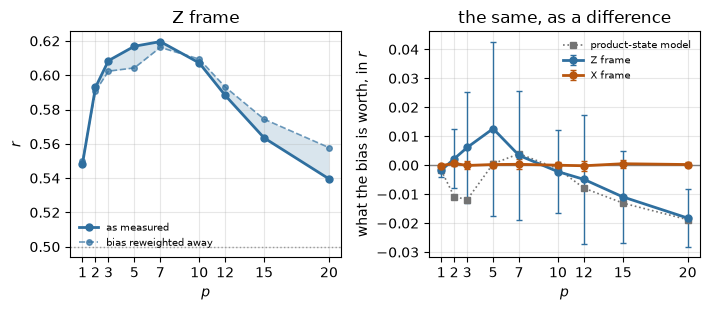

In [ ]:
from qecbench.analysis import instance_from_record


def score_three_ways(path):
    # per depth: r as measured, r with the marginals forced to 1/2, r of an uncorrelated state at those marginals
    out = defaultdict(list)
    for record in json.loads(Path(path).read_text())["results"]:
        instance = instance_from_record(record)
        if instance is None or instance.code.info.get("distance") != DISTANCE:
            continue
        counts, parameters = record["samples"], record["parameters"]
        keys = list(counts)
        bits = np.frombuffer("".join(keys).encode(), dtype=np.uint8).reshape(len(keys), -1) - 48
        weights = np.array([counts[k] for k in keys], float)
        p1 = np.clip((weights @ bits) / weights.sum(), 1e-3, 1 - 1e-3)
        flat = weights * np.prod(np.where(bits == 1, 0.5 / p1, 0.5 / (1 - p1)), axis=1)
        energies = bitstring_energies(keys, instance.hamiltonian)
        e_opt, e_max = instance.optimal_energy(), instance.max_energy()
        r_of = lambda energy: (energy - e_max) / (e_opt - e_max)
        z_expectation = 1 - 2 * p1                        # the uncorrelated state at the same marginals
        product = sum(c * np.prod([z_expectation[i] for i in term])
                      for term, c in instance.hamiltonian.items())
        out[parameters["depth"]].append((r_of((weights @ energies) / weights.sum()),
                                         r_of((flat @ energies) / flat.sum()),
                                         r_of(product), float(np.mean(p1 - 0.5))))
    return {depth: np.array(rows) for depth, rows in sorted(out.items())}


gain = {}
for frame, path in (("Z", files[0]), ("X", files[1])):
    gain[frame] = score_three_ways(path)
shown = sorted(gain["Z"])
print(f"{stamp}, Z frame: what the bias is worth, in r\n")
print(f"{'depth':>6} {'bias':>8} {'r measured':>12} {'r unbiased':>12} {'the bias is worth':>19} "
      f"{'product model':>15}")
for depth in shown:
    rows = gain["Z"][depth]
    print(f"{depth:>6} {rows[:, 3].mean():>+8.3f} {rows[:, 0].mean():>12.4f} {rows[:, 1].mean():>12.4f} "
          f"{rows[:, 0].mean() - rows[:, 1].mean():>+19.4f} {rows[:, 2].mean() - 0.5:>+15.4f}")
print("\n'the bias is worth' is r as measured minus r with the marginals flattened, keeping the correlations;")
print("'product model' is what an uncorrelated state at the same marginals scores, relative to 1/2.")

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
rows_z = np.array([gain["Z"][d][:, 0].mean() for d in shown])
flat_z = np.array([gain["Z"][d][:, 1].mean() for d in shown])
axes[0].plot(shown, rows_z, "-o", color="#2f6f9f", lw=2, ms=5, label="as measured")
axes[0].plot(shown, flat_z, "--o", color="#2f6f9f", lw=1.2, ms=4, alpha=0.7, label="bias reweighted away")
axes[0].fill_between(shown, flat_z, rows_z, color="#2f6f9f", alpha=0.18, lw=0)
axes[0].axhline(0.5, color="0.6", ls=":", lw=1)
axes[0].set(xlabel="$p$", ylabel="$r$", title="Z frame")
axes[0].set_xticks(shown)
axes[0].legend(fontsize=7, frameon=False)
for frame, colour in (("Z", "#2f6f9f"), ("X", "#b8560f")):
    middle = [gain[frame][d][:, 0].mean() - gain[frame][d][:, 1].mean() for d in shown]
    spread = [(gain[frame][d][:, 0] - gain[frame][d][:, 1]).std() for d in shown]
    axes[1].errorbar(shown, middle, yerr=spread, fmt="-o", color=colour, lw=2, ms=5, capsize=2.5,
                     elinewidth=1, label=f"{frame} frame")
axes[1].plot(shown, [gain["Z"][d][:, 2].mean() - 0.5 for d in shown], ":s", color="0.45", lw=1.2, ms=4,
             label="product-state model")
axes[1].axhline(0, color="0.5", lw=1)
axes[1].set(xlabel="$p$", ylabel="what the bias is worth, in $r$", title="the same, as a difference")
axes[1].set_xticks(shown)
axes[1].legend(fontsize=7, frameon=False)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / f"{BACKEND}_bias_worth.pdf", bbox_inches="tight")
plt.show()

### 8b. The same, over every run

One run could put the crossing anywhere. This repeats the counterfactual on every run that carries both frames and
counts how many of them agree on the sign, depth by depth.

In [ ]:
print("what the bias is worth in r, Z frame, run by run  (positive: the bias raises the score)\n")
across = defaultdict(list)
print(f"{'run':>14} " + "".join(f"{'p=' + str(p):>9}" for p in shown))
for st, (z_path, x_path) in pairs.items():
    got = score_three_ways(z_path)
    row = []
    for depth in shown:
        if depth in got:
            value = got[depth][:, 0].mean() - got[depth][:, 1].mean()
            across[depth].append(value)
            row.append(f"{value:>+9.4f}")
        else:
            row.append(f"{'':>9}")
    print(f"{st:>14} " + "".join(row))
print(f"{'mean':>14} " + "".join(f"{np.mean(across[d]):>+9.4f}" if across[d] else f"{'':>9}" for d in shown))
print(f"{'runs raised':>14} " + "".join((f"{sum(1 for v in across[d] if v > 0)}/{len(across[d])}").rjust(9)
                                        if across[d] else f"{'':>9}" for d in shown))

what the bias is worth in r, Z frame, run by run  (positive: the bias raises the score)

           run       p=1      p=2      p=3      p=5      p=7     p=10     p=12     p=15     p=20
 20260922_1326   -0.0026  +0.0010  +0.0065  +0.0073  +0.0094  -0.0082                           
 20260923_0715   -0.0002  +0.0000  +0.0093  +0.0097  +0.0035  -0.0037                           
 20260923_1635   -0.0015  +0.0048  +0.0224  +0.0083  +0.0105  -0.0058                           
 20260924_0804   -0.0024  +0.0025  +0.0045  +0.0081  +0.0098  +0.0019                           
 20260926_0857   -0.0011  +0.0019  +0.0024  -0.0007  +0.0142  +0.0002                           
 20260926_1311   -0.0019  +0.0014  +0.0075  +0.0235  +0.0177  +0.0004                           
 20260928_0812   -0.0010  +0.0081  +0.0194  +0.0242  +0.0152  +0.0095                           
 20260928_0900   -0.0018  +0.0022  +0.0061  +0.0126  +0.0034  -0.0022  -0.0049  -0.0109  -0.0182
          mean   -0.0016  +0.0028  +0.

## 9. What the run says

Fill this in from the cells above; the numbers that mattered when this notebook was written were:

* the noiseless marginals are $1/2$ to $10^{-15}$, so every departure measured here is noise;
* the $Z$ frame is biased toward $|0\rangle$ by about an eighth of a shot and varies five times more between
  qubits than the $X$ frame does, which sits near zero - consistent with the data relaxing in $Z$ eigenstates in
  one frame and being randomised rather than pulled in the other;
* the bias grows to $p \approx 3$ and then saturates, as relaxation toward a fixed point would;
* the stored calibration does **not** rank the biased qubits, $T_1$ least of all, so this is not a number that can
  be read off a snapshot;
* the random baseline is optimistic for a biased patch: a fully decohered patch scores below $1/2$, so a small or
  negative $r_{\rm ovl}$ in the $Z$ frame should be read against the floor of section 6, not against $1/2$;
* the bias is worth a real amount of score: reweighted away, $r_{\rm ovl}^Z$ **falls** at $p = 2$ to $7$ and
  rises again past $p \approx 10$, so the shallow depths - the ones a cheap protocol would use - read high by
  about $0.01$ in $r$ for reasons that have nothing to do with the algorithm. An uncorrelated state at the same
  marginals scores *below* $1/2$, so the gain is carried by the correlations the bias arrives with, not by the
  marginals themselves. The X frame shows none of it;
* and the bias is a **property of the qubit, not of the day**: over a week of runs the chip-wide mean holds to a
  few parts in a thousand, every pair of runs agrees on the ranking, and about seven eighths of the spread sits
  between qubits rather than between runs. It is the one quantity in this study that a single run can be trusted
  to measure.